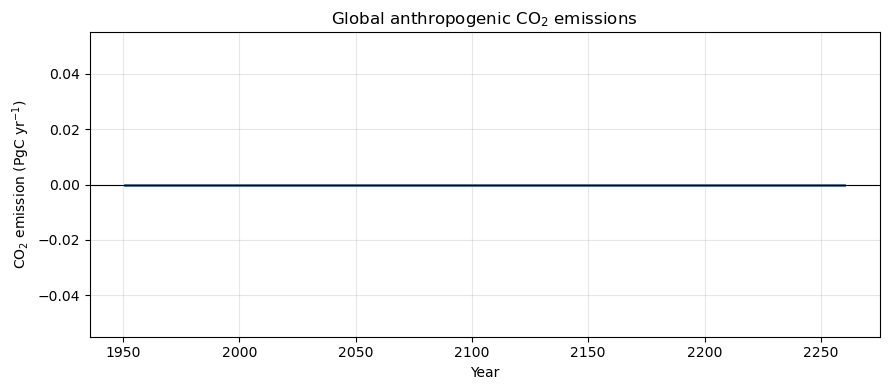

      CO2_emission_PgC_yr
year                     
1951                  0.0
1952                  0.0
1953                  0.0
1954                  0.0
1955                  0.0
      CO2_emission_PgC_yr
year                     
2256                  0.0
2257                  0.0
2258                  0.0
2259                  0.0
2260                  0.0
Min: 0.0
Max: 0.0


In [1]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# Input file
# ============================================================

infile = (
    "/nird/datalake/NS2980K/projects/TipESM/inputdata/emissions/"
    "emissions-TIPMIP_CO2_anthro_surface_195101-225012_fv_1.9x2.5_esm-up2p0-swl2p0.nc"
)

ds = xr.open_dataset(infile)

co2flux = ds["CO2_flux"]   # kg m-2 s-1


# ============================================================
# Grid-cell area for regular lat-lon grid
# ============================================================

R_earth = 6371000.0  # m

lat = ds["lat"]
lon = ds["lon"]

# Infer grid spacing
dlat = np.abs(lat[1] - lat[0])
dlon = np.abs(lon[1] - lon[0])

# Convert to radians
dlat_rad = np.deg2rad(dlat)
dlon_rad = np.deg2rad(dlon)

lat_rad = np.deg2rad(lat)

# Area of each latitude band grid cell
area_lat = (R_earth**2) * dlon_rad * (
    np.sin(lat_rad + dlat_rad / 2) - np.sin(lat_rad - dlat_rad / 2)
)

area = area_lat.broadcast_like(co2flux.isel(time=0))


# ============================================================
# Global total CO2 emission
# kg m-2 s-1 -> kg s-1 -> PgC yr-1
# ============================================================

sec_per_year = 365 * 24 * 3600
kg_to_Pg = 1e-12

co2_emis_PgC_yr = (co2flux * area).sum(dim=["lat", "lon"]) * sec_per_year * kg_to_Pg

co2_emis_PgC_yr.name = "CO2_emission_PgC_yr"
co2_emis_PgC_yr.attrs["units"] = "PgC yr-1"


# ============================================================
# Convert monthly time to annual mean / annual total-style series
# Since flux is already kg m-2 s-1, annual mean flux converted to PgC/yr is appropriate.
# ============================================================

co2_emis_annual = co2_emis_PgC_yr.groupby("time.year").mean("time")


# ============================================================
# Plot
# ============================================================

plt.figure(figsize=(9, 4))

plt.plot(
    co2_emis_annual["year"],
    co2_emis_annual,
    lw=2
)

plt.axhline(0, color="k", lw=0.8)

plt.xlabel("Year")
plt.ylabel("CO$_2$ emission (PgC yr$^{-1}$)")
plt.title("Global anthropogenic CO$_2$ emissions")

plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


# ============================================================
# Quick check
# ============================================================

print(co2_emis_annual.to_dataframe().head())
print(co2_emis_annual.to_dataframe().tail())
print("Min:", float(co2_emis_annual.min()))
print("Max:", float(co2_emis_annual.max()))

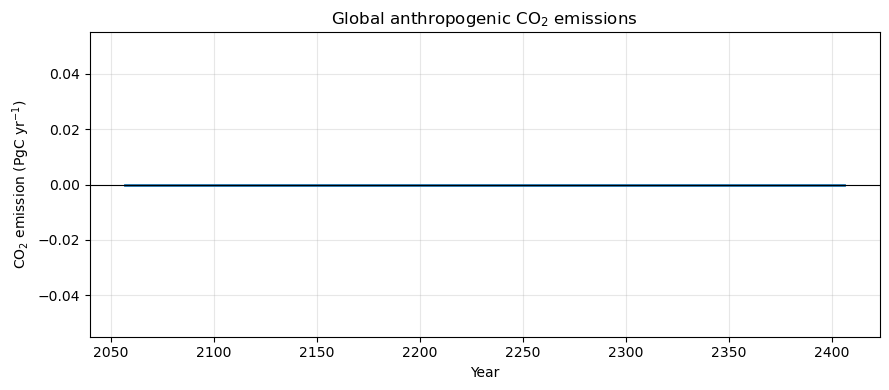

      CO2_emission_PgC_yr
year                     
2057                  0.0
2058                  0.0
2059                  0.0
2060                  0.0
2061                  0.0
      CO2_emission_PgC_yr
year                     
2402                  0.0
2403                  0.0
2404                  0.0
2405                  0.0
2406                  0.0
Min: 0.0
Max: 0.0


In [5]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# Input file
# ============================================================

infile = (
    "/nird/datalake/NS2980K/projects/TipESM/inputdata/emissions/"
    "emissions-TIPMIP_CO2_anthro_surface_205701-235612_fv_1.9x2.5_esm-up2p0-swl4p0.nc"
)

ds = xr.open_dataset(infile)

co2flux = ds["CO2_flux"]   # kg m-2 s-1


# ============================================================
# Grid-cell area for regular lat-lon grid
# ============================================================

R_earth = 6371000.0  # m

lat = ds["lat"]
lon = ds["lon"]

# Infer grid spacing
dlat = np.abs(lat[1] - lat[0])
dlon = np.abs(lon[1] - lon[0])

# Convert to radians
dlat_rad = np.deg2rad(dlat)
dlon_rad = np.deg2rad(dlon)

lat_rad = np.deg2rad(lat)

# Area of each latitude band grid cell
area_lat = (R_earth**2) * dlon_rad * (
    np.sin(lat_rad + dlat_rad / 2) - np.sin(lat_rad - dlat_rad / 2)
)

area = area_lat.broadcast_like(co2flux.isel(time=0))


# ============================================================
# Global total CO2 emission
# kg m-2 s-1 -> kg s-1 -> PgC yr-1
# ============================================================

sec_per_year = 365 * 24 * 3600
kg_to_Pg = 1e-12

co2_emis_PgC_yr = (co2flux * area).sum(dim=["lat", "lon"]) * sec_per_year * kg_to_Pg

co2_emis_PgC_yr.name = "CO2_emission_PgC_yr"
co2_emis_PgC_yr.attrs["units"] = "PgC yr-1"


# ============================================================
# Convert monthly time to annual mean / annual total-style series
# Since flux is already kg m-2 s-1, annual mean flux converted to PgC/yr is appropriate.
# ============================================================

co2_emis_annual = co2_emis_PgC_yr.groupby("time.year").mean("time")


# ============================================================
# Plot
# ============================================================

plt.figure(figsize=(9, 4))

plt.plot(
    co2_emis_annual["year"],
    co2_emis_annual,
    lw=2
)

plt.axhline(0, color="k", lw=0.8)

plt.xlabel("Year")
plt.ylabel("CO$_2$ emission (PgC yr$^{-1}$)")
plt.title("Global anthropogenic CO$_2$ emissions")

plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


# ============================================================
# Quick check
# ============================================================

print(co2_emis_annual.to_dataframe().head())
print(co2_emis_annual.to_dataframe().tail())
print("Min:", float(co2_emis_annual.min()))
print("Max:", float(co2_emis_annual.max()))